## Borrower Reliability Case Study

The client is a bank's credit department. It is necessary to determine whether a client's marital status and number of children affect their ability to repay a loan on time. The bank's input data consists of client solvency statistics.

The study results will be taken into account when developing a **credit scoring** model — a specialized system that evaluates a potential borrower's ability to repay a loan to the bank.

## Contents:
* [Step 1. General Information](#first-bullet)
* [Step 2. Data Preprocessing](#second-bullet)
* 2.1. [Duplicates Handling](#second-1-bullet)
* 2.2. [Missing Data Handling](#second-2-bullet)
* 2.3. [Data Type Replacement](#second-3-bullet)
* 2.4. [Lemmatization](#second-4-bullet)
* 2.5. [Data Categorization](#second-5-bullet)
* [Step 3. Exploratory Data Analysis](#third-bullet)
* 3.1. [Is There a Relationship Between Having Children and On-Time Loan Repayment](#third-1-bullet)
* 3.2. [Is there a relationship between marital status and on-time loan repayment?](#third-2-bullet)
* 3.3. [Is there a relationship between income level and on-time loan repayment?](#third-3-bullet)
* 3.4. [How do different loan purposes affect on-time loan repayment?](#third-4-bullet)
* [Step 4. General conclusion](#thourth-bullet)

### Step 1. General Information<a class="anchor" id="first-bullet"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/data.csv')

In [3]:
df.head()

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875.639453,покупка жилья
1,1,-4024.803754,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080.014102,приобретение автомобиля
2,0,-5623.422610,33,Среднее,1,женат / замужем,0,M,сотрудник,0,145885.952297,покупка жилья
3,3,-4124.747207,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628.550329,дополнительное образование
4,0,340266.072047,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616.077870,сыграть свадьбу


**Data Description:**

* children — number of children in the family
* days_employed — total work experience in days
* dob_years — client's age in years
* education — client's education level
* education_id — education level identifier
* family_status — marital status
* family_status_id — marital status identifier
* gender — client's gender
* income_type — employment type
* debt — whether the client was in arrears on loans
* total_income — monthly income
* purpose — purpose of the loan

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


    The table has 12 columns and 21,525 rows.
    Two columns, ['days_employed'] and ['total_income'], contain missing NaN values.
    The cells are missing numbers; the data type is float.
    The missing values ​​have to be removed.
    The 'days_employed' column is not needed for solving the problems.
    The 'total_income' column is needed for solving the problems.

### Step 2. Data Preprocessing<a class="anchor" id="second-bullet"></a>

### 2.1. Duplicates Handling<a class="anchor" id="second-1-bullet"></a>

In [5]:
df.duplicated().sum()

54

The dataset contains 21 525 rows, 54 of which are complete duplicates. Duplicates account for 0.25% of the dataset. We will remove duplicate rows.

In [6]:
df.drop_duplicates().reset_index(drop = True)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875.639453,покупка жилья
1,1,-4024.803754,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080.014102,приобретение автомобиля
2,0,-5623.422610,33,Среднее,1,женат / замужем,0,M,сотрудник,0,145885.952297,покупка жилья
3,3,-4124.747207,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628.550329,дополнительное образование
4,0,340266.072047,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616.077870,сыграть свадьбу
...,...,...,...,...,...,...,...,...,...,...,...,...
21466,1,-4529.316663,43,среднее,1,гражданский брак,1,F,компаньон,0,224791.862382,операции с жильем
21467,0,343937.404131,67,среднее,1,женат / замужем,0,F,пенсионер,0,155999.806512,сделка с автомобилем
21468,1,-2113.346888,38,среднее,1,гражданский брак,1,M,сотрудник,1,89672.561153,недвижимость
21469,3,-3112.481705,38,среднее,1,женат / замужем,0,M,сотрудник,1,244093.050500,на покупку своего автомобиля


In [7]:
df['education'].value_counts()

среднее                13750
высшее                  4718
СРЕДНЕЕ                  772
Среднее                  711
неоконченное высшее      668
ВЫСШЕЕ                   274
Высшее                   268
начальное                250
Неоконченное высшее       47
НЕОКОНЧЕННОЕ ВЫСШЕЕ       29
НАЧАЛЬНОЕ                 17
Начальное                 15
ученая степень             4
Ученая степень             1
УЧЕНАЯ СТЕПЕНЬ             1
Name: education, dtype: int64

    The value_counts() method found duplicates in the ['education'] column.
    There are 5 unique values, but due to case differences, there are 15 values ​​in the table.
    Let's convert all values ​​to lowercase.

In [8]:
df['education'] = df['education'].str.lower()
df['education'].value_counts()

среднее                15233
высшее                  5260
неоконченное высшее      744
начальное                282
ученая степень             6
Name: education, dtype: int64

    To eliminate duplicates, all characters in the string have been converted to lowercase
    by calling the lower() method. To ensure there is no more duplicates, the value_counts() method has been called again.
    Duplicates could have been caused by human error,
    when entering case-insensitive information.
    No duplicates have been found in other columns.
  

### 2.2. Missing Data Handling<a class="anchor" id="second-2-bullet"></a>

    We found missing data in the ['total_income'] column.
    Let's examine the data in this column to decide how to fill in the gaps correctly.

In [9]:
df['total_income'].describe().round(2)

count      19351.00
mean      167422.30
std       102971.57
min        20667.26
25%       103053.15
50%       145017.94
75%       203435.07
max      2265604.03
Name: total_income, dtype: float64

    The average monthly income of the bank's clients is 167 422 rubles.
    25% of clients have a monthly income of 103 053 rubles.
    50% of clients have a monthly income of 145 017 rubles or less.
    75% of clients have a monthly income of 203 435 rubles or less.
    The largest outlier in the data is an income of 2 265 604 rubles per month.
    Standard deviation: 102 971.57
    Because the standard deviation is large, the dataset may contain significant anomalies or outliers.


<AxesSubplot:>

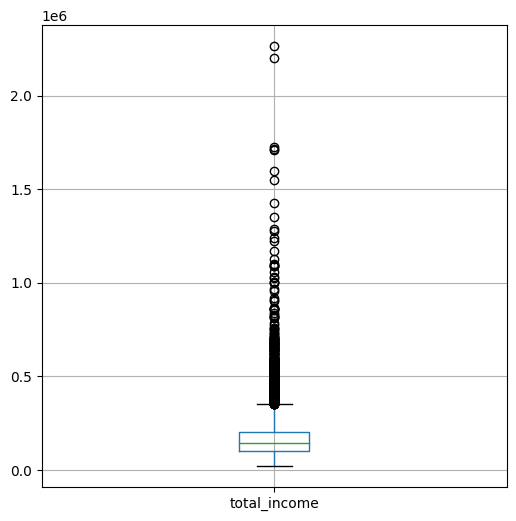

In [10]:
df.boxplot(column='total_income', figsize=(6,6))

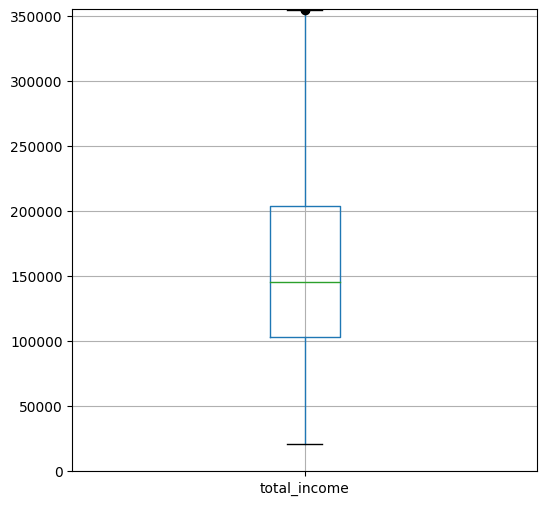

In [11]:
df.boxplot(column='total_income', figsize=(6,6))
plt.ylim(0, 355000)
plt.show()

    The outliers start at an income of 355 000 rubles per month.
    Let's remove the outliers and look at the cleaned data values.

In [12]:
df_total_income = df.query('total_income <= total_income.quantile(0.95)')
df_total_income['total_income'].describe().round()

count     18383.0
mean     151685.0
std       66101.0
min       20667.0
25%      101086.0
50%      140916.0
75%      192625.0
max      340546.0
Name: total_income, dtype: float64

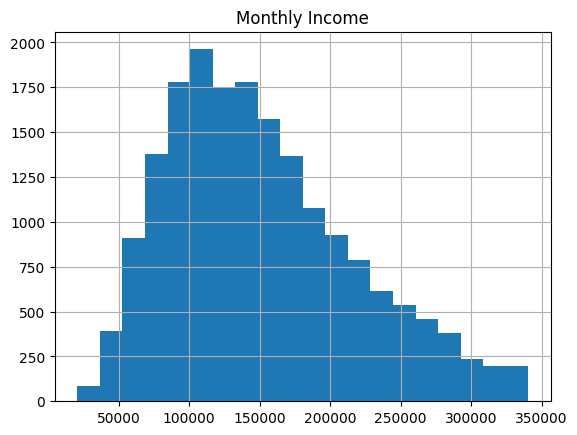

In [13]:
df_total_income['total_income'].hist(bins=20, color = 'C0')
plt.title('Monthly Income')
plt.show()

    Let's replace the gaps in the ['total_income'] column with the median in the cleaned data - 140 916 rubles/month.

In [14]:
average_income = 140916
df['total_income'] = df['total_income'].fillna(value=average_income)

    Since the 'days_employed' column is not needed to answer the question, this column will be removed.
    It also contained negative values, which cannot be correct.
    This should be communicated to colleagues, as this column may be needed when solving other problems.

In [15]:
df.drop('days_employed', axis=1, inplace=True)

    Making sure that the table no longer contains gaps.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   dob_years         21525 non-null  int64  
 2   education         21525 non-null  object 
 3   education_id      21525 non-null  int64  
 4   family_status     21525 non-null  object 
 5   family_status_id  21525 non-null  int64  
 6   gender            21525 non-null  object 
 7   income_type       21525 non-null  object 
 8   debt              21525 non-null  int64  
 9   total_income      21525 non-null  float64
 10  purpose           21525 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 1.8+ MB


**Conclusion:**

    The errors in the ['days_employed'] and ['total_income'] columns are caused by:
    either technological errors (data entry issues) or human error,
    uncertainty about monthly income and work experience. The team should be warned so that
    the causes can be identified. All omitted values have been identified and corrected.


### 2.3. Data type Replacement <a class="anchor" id="second-3-bullet"></a>

In [17]:
df['total_income'] = df['total_income'].astype('int') 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   children          21525 non-null  int64 
 1   dob_years         21525 non-null  int64 
 2   education         21525 non-null  object
 3   education_id      21525 non-null  int64 
 4   family_status     21525 non-null  object
 5   family_status_id  21525 non-null  int64 
 6   gender            21525 non-null  object
 7   income_type       21525 non-null  object
 8   debt              21525 non-null  int64 
 9   total_income      21525 non-null  int64 
 10  purpose           21525 non-null  object
dtypes: int64(6), object(5)
memory usage: 1.8+ MB


    In the ['total_income'] column, the float data type was changed to integer using the astype() method. 
    The ('int') argument means to convert it to an integer.
    It will be more convenient to work with integers when calculating.

### 2.4. Lemmatization<a class="anchor" id="second-4-bullet"></a>

In [18]:
from pymystem3 import Mystem
m = Mystem()
def lemmatizator(i):
    lemmas = m.lemmatize(i)
    return lemmas

df['purpose_lemmas'] = df['purpose'].apply(lemmatizator)
df.head()

,children,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose,purpose_lemmas
0,1,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875,покупка жилья,"[покупка, , жилье, \n]"
1,1,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080,приобретение автомобиля,"[приобретение, , автомобиль, \n]"
2,0,33,среднее,1,женат / замужем,0,M,сотрудник,0,145885,покупка жилья,"[покупка, , жилье, \n]"
3,3,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628,дополнительное образование,"[дополнительный, , образование, \n]"
4,0,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616,сыграть свадьбу,"[сыграть, , свадьба, \n]"


    The ['purpose'] column is inconvenient for analysis because it contains duplicated purposes.
    The 'wedding', 'housing', 'real estate', 'car', and 'education' purposes are written in different ways.
    This resulted in 38 purposes instead of 5.
    The nouns are written in different cases, making it difficult to search for meanings and assign them to categories.

    To lemmatize the loan purposes in the 'purpose' column, the function
    def lemmatizator() was written. The resulting lemmatized values ​​were added to a new column
    'purpose_lemmas'. Now there's a column in which all nouns are written in the
    nominative case and singular, meaning they match in form.

    To check the result, we displayed the first 5 rows.

### 2.5. Data Categorization<a class="anchor" id="second-5-bullet"></a>

    A study of 2019 data on the categorization of the Russian population was conducted 
    based on monthly income level. Seven categories were identified: poor,
    low-income, lower middle class, middle class, upper middle class,
    wealthy, and rich. The bank's statistics do not include a "poor" category,
    so six categories are used below.

In [19]:
def name_income_level(salary):
    if 20000 < salary < 30000:
        return 'low-income'
    if 30000 < salary < 50000:
        return 'lower  middle class'
    if 50000 < salary < 70000:
        return 'middle class'
    if 70000 < salary < 120000:
        return 'upper middle class'
    if 120000 < salary < 150000:
        return 'wealthy'
    return 'rich'

#проверка функции для каждой категории
print(name_income_level(25000)) 
print(name_income_level(45000))
print(name_income_level(65000))
print(name_income_level(100000))
print(name_income_level(130000))
print(name_income_level(160000))

low-income
lower  middle class
middle class
upper middle class
wealthy
rich


    The name_income_level() function was created, 
    which assigns a client a wealth category based on their monthly income.

In [20]:
df['income_level'] = df['total_income'].apply(name_income_level)
df['income_level'].value_counts()

rich                   9184
wealthy                5496
upper middle class     5371
middle class           1102
lower  middle class     350
low-income               22
Name: income_level, dtype: int64

Text(0.5, 1.0, 'Clients Categories by Monthly Income')

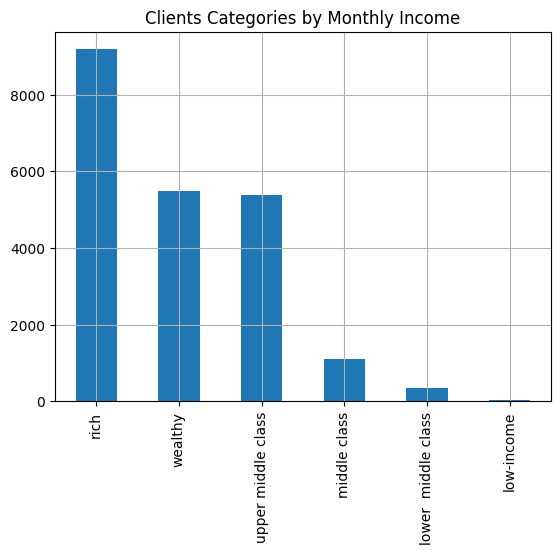

In [21]:
df['income_level'].value_counts(ascending=False).plot(y='income_level', kind='bar', grid=True)
plt.title('Clients Categories by Monthly Income')

    The results of the name_income_level() function have been added to the table as a separate column.
    Now it will be convenient for grouping. We can compare clients from different categories
    by monthly income.

    We see that the majority of the bank's clients fall into the "rich" category, with a monthly income
    of 150 000 rubles/month (9 184 clients).

    The second largest category is "wealthy" clients with a monthly income
    of 120 000 rubles/month to 150 000 rubles/month (5 496 clients).

    The third largest category is upper middle class clients, with a monthly income
    of 70 000 to 120 000 rubles/month. 

**Категоризация целей**

In [22]:
def target_category(purpose_lemmas):
    if 'жилье' in purpose_lemmas:
        return 'housing'
    elif 'недвижимость' in purpose_lemmas:
        return 'real estate'
    elif 'свадьба' in purpose_lemmas:
        return 'wedding'
    elif 'автомобиль' in purpose_lemmas:
        return 'car'
    else:
        return 'education'
df['target_category'] = df['purpose_lemmas'].apply(target_category)


In [23]:
df['target_category'].value_counts()

real estate    6367
housing        4473
car            4315
education      4022
wedding        2348
Name: target_category, dtype: int64

In [24]:
df.head()

,children,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose,purpose_lemmas,income_level,target_category
0,1,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875,покупка жилья,"[покупка, , жилье, \n]",rich,housing
1,1,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080,приобретение автомобиля,"[приобретение, , автомобиль, \n]",upper middle class,car
2,0,33,среднее,1,женат / замужем,0,M,сотрудник,0,145885,покупка жилья,"[покупка, , жилье, \n]",wealthy,housing
3,3,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628,дополнительное образование,"[дополнительный, , образование, \n]",rich,education
4,0,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616,сыграть свадьбу,"[сыграть, , свадьба, \n]",rich,wedding


* To categorize goals, a function was written that searches for goals in a list of lemmas.
* The result of the target_category() function was added as a separate column.
* The most common loan purpose is real estate.
        
    

Text(0.5, 1.0, 'Loan Purpose')

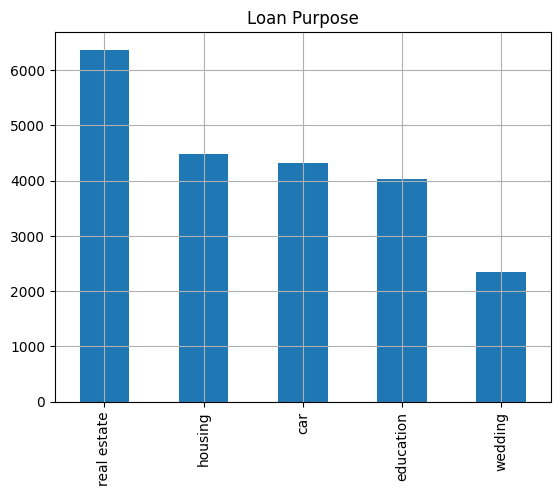

In [25]:
df['target_category'].value_counts(ascending=False).plot(y='target_category', kind='bar', grid=True)
plt.title('Loan Purpose')

    To answer the questions, it was necessary to identify certain categories.
    The first category was based on income level, and the second category was based on goal types.

### Step 3. Exploratory Data Analysis <a class="anchor" id="third-bullet"></a>

### 3.1. Is There a Relationship Between Having Children and On-Time Loan Repayment?<a class="anchor" id="third-1-bullet"></a>

In [26]:
df['children'].value_counts()

 0     14149
 1      4818
 2      2055
 3       330
 20       76
-1        47
 4        41
 5         9
Name: children, dtype: int64

Incorrect data was found in the ['children'] column:
* -1 child for 47 people and 20 children for 76 people.
* Most likely, this refers to 1 child and 2 children, making these duplicates.
* Incorrect values ​​must be replaced with correct ones.

In [27]:
df['children'] = df['children'].replace(-1, 1)
df['children'] = df['children'].replace(20, 2)
df['children'].value_counts()

0    14149
1     4865
2     2131
3      330
4       41
5        9
Name: children, dtype: int64

In [28]:
children = df.pivot_table(index= 'children', values= 'debt', aggfunc= ['count', 'sum', 'mean']).reset_index()
children.columns = ['children', 'quantity_clients', 'quantity_debtors', 'ratio']
children

,children,quantity_clients,quantity_debtors,ratio
0,0,14149,1063,0.075129
1,1,4865,445,0.091470
2,2,2131,202,0.094791
3,3,330,27,0.081818
4,4,41,4,0.097561
5,5,9,0,0.000000


Text(0.5, 1.0, 'Relationship between Having Children and On-Time Loan Repayment')

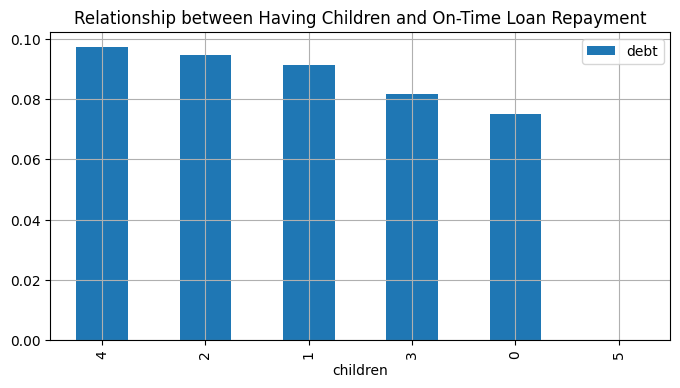

In [29]:
df.pivot_table(index='children', values='debt', aggfunc='mean').sort_values(by='debt', ascending=False).plot(kind='bar', grid=True, figsize=(8, 4))
plt.title('Relationship between Having Children and On-Time Loan Repayment')

    Bank clients with five children have no late loan repayments. 
    However, they represent only 0.04% of the total number of clients. 
    Therefore, it would be wrong to conclude that the more children in a family, 
    the lower the risk of late loan repayments. (This is a small group, so statistics may be incorrect.)

    Clients without children (0.075) are in second place. 
    This is the largest group of clients (65.73% of the total). 
    Therefore, clients without children are the most likely to take out loans and the least likely to be late.

    Clients with one to four children show similar results: from 0.098 to 0.082.


    Let's look at the Pearson coefficient. 
    How does the presence of children influence late payments overall?

In [30]:
df['children'].corr(df['debt'])

0.024989833706762547

    The closer the Pearson coefficient is to 1, the stronger the relationship.
    In this case, there is a slight positive correlation (coefficient - 0.25).

### 3.2. Is there a relationship between marital status and on-time loan repayment?<a class="anchor" id="third-2-bullet"></a>


In [31]:
family_status = df.pivot_table(index= 'family_status', values= 'debt', aggfunc= ['count', 'sum', 'mean']).reset_index()
family_status.columns = ['family_status', 'quantity_clients', 'quantity_debtors', 'ratio']
family_status

,family_status,quantity_clients,quantity_debtors,ratio
0,Не женат / не замужем,2813,274,0.097405
1,в разводе,1195,85,0.071130
2,вдовец / вдова,960,63,0.065625
3,гражданский брак,4177,388,0.092890
4,женат / замужем,12380,931,0.075202


Text(0.5, 1.0, 'Relationship between Marital Status and On-Time Loan Repayment')

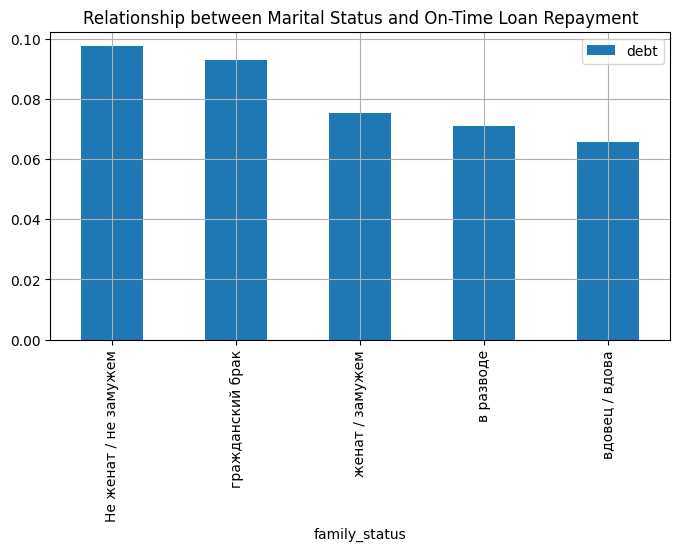

In [32]:
df.pivot_table(index= 'family_status', values= 'debt', aggfunc='mean').sort_values(by='debt', ascending=False).plot(kind='bar', grid=True, figsize=(8, 4))
plt.title('Relationship between Marital Status and On-Time Loan Repayment')

- Clients who are single are most likely to be late with their loan payments.
- Clients who are widowed are the least likely to be late with their loan payments.

Both client groups are considered single. To determine the correlation, we will expand the groups to include single/not single (married or co-living).

In [33]:
def target_family_status(family_status):
    if 'Не женат / не замужем' in family_status:
        return 'single'
    elif 'в разводе' in family_status:
        return 'single'
    elif 'вдовец / вдова' in family_status:
        return 'single'
    elif 'гражданский брак' in family_status:
        return 'not single'
    else:
        return 'not single'
df['target_family_status'] = df['family_status'].apply(target_family_status)

In [34]:
family_status_cor = df.pivot_table(index= 'target_family_status', values= 'debt', aggfunc= ['count', 'sum', 'mean']).reset_index()
family_status_cor.columns = ['family_status', 'quantity_clients', 'quantity_debtors', 'ratio']
family_status_cor

,family_status,quantity_clients,quantity_debtors,ratio
0,not single,16557,1319,0.079664
1,single,4968,422,0.084944


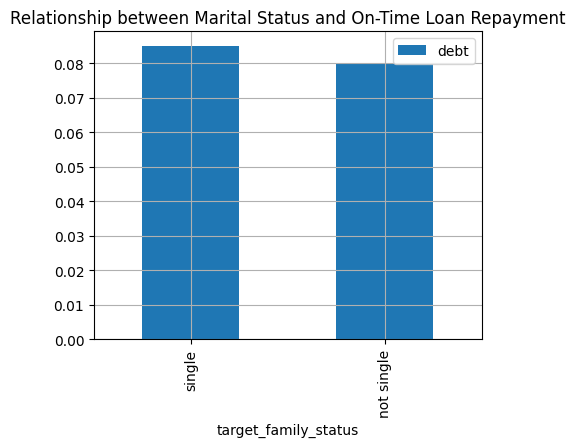

In [35]:
df.pivot_table(index= 'target_family_status', values= 'debt', aggfunc='mean').sort_values(by='debt', ascending=False).plot(kind='bar', grid=True, figsize=(5, 4))
plt.title('Relationship between Marital Status and On-Time Loan Repayment')
plt.show()

    When combining several groups into two larger groups (single/not single), 
    it turned out that people who are married or in a co-living relationship are less likely to default on loan payments.

    Also, people who are married or in a co-living relationship are more likely to take out loans than single people.



### 3.3. Is there a relationship between income level and on-time loan repayment?<a class="anchor" id="third-3-bullet"></a>

In [36]:
income_level = df.pivot_table(index= 'income_level', values= 'debt', aggfunc= ['count', 'sum', 'mean']).reset_index()
income_level.columns = ['income_level', 'quantity_clients', 'quantity_debtors', 'ratio']
income_level

,income_level,quantity_clients,quantity_debtors,ratio
0,low-income,22,2,0.090909
1,lower middle class,350,21,0.060000
2,middle class,1102,78,0.070780
3,rich,9184,726,0.079051
4,upper middle class,5371,450,0.083783
5,wealthy,5496,464,0.084425


Text(0.5, 1.0, 'Relationship between Income Level and On-Time Loan Repayment')

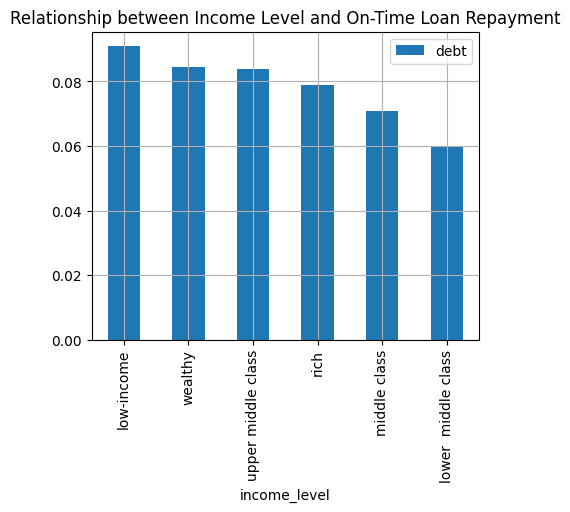

In [37]:
df.pivot_table(index= 'income_level', values= 'debt', aggfunc='mean').sort_values(by='debt', ascending=False).plot(kind='bar', grid=True, figsize=(5, 4))
plt.title('Relationship between Income Level and On-Time Loan Repayment')

    Lower-middle-class clients (50 000-70 000 rubles per month) are the least likely to default on loan payments.

    Middle-class clients (70 000-120 000 rubles per month) are the second-most likely to default.

    Low-income clients (20 000-30 000 rubles per month) are the most likely to default on loan payments.

### 3.4. How do different loan purposes affect on-time loan repayment?<a class="anchor" id="third-4-bullet"></a>

In [38]:
target_category = df.pivot_table(index= 'target_category', values= 'debt', aggfunc= ['count', 'sum', 'mean']).reset_index()
target_category.columns = ['target_category', 'quantity_clients', 'quantity_debtors', 'ratio']
target_category

,target_category,quantity_clients,quantity_debtors,ratio
0,car,4315,403,0.093395
1,education,4022,370,0.091994
2,housing,4473,308,0.068858
3,real estate,6367,474,0.074446
4,wedding,2348,186,0.079216


Text(0.5, 1.0, 'Relationship between Loan Purposes and On-Time Loan Repayment')

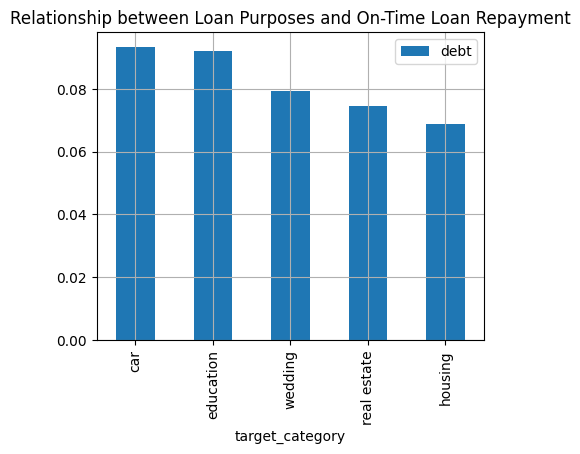

In [39]:
df.pivot_table(index= 'target_category', values= 'debt', aggfunc='mean').sort_values(by='debt', ascending=False).plot(kind='bar', grid=True, figsize=(5, 4))
plt.title('Relationship between Loan Purposes and On-Time Loan Repayment')

    Clients taking out car and education loans are more likely to default on their payments.

    Clients taking out home loans are less likely to default on their payments.

### Шаг 4. General Conclusion <a class="anchor" id="thourth-bullet"></a>

When analyzing the bank's customer solvency statistics, the following results were obtained:

1. Customers without children are the most likely to take out loans and the least likely to be late with payments.

2. Customers who are married or in a common-law relationship are the most likely to take out loans and the least likely to default on loan payments.

3. Customers in the lower middle class (50,000-70,000 rubles per month) are the least likely to default on loan payments.
Customers in the low-income group (20,000-30,000 rubles per month) are the most likely to default on loan payments.

4. Customers taking out car and education loans are the most likely to default on their payments.
Customers taking out housing loans are the least likely to default on their payments.
